# Data import
Just about reading the CSV and looking at basic facts. I'm aware of the risks that come with CSV; I know that floats tend to uh get truncated or rounded 

In [57]:
from pathlib import Path 
import numpy as np
import pandas as pd 
from pandas import DataFrame

measurements = pd.read_csv(
    Path("output.3.csv"), 
    skip_blank_lines=True, 
    header=0)

measurements["latency"] = pd.to_numeric(measurements.latency, errors='coerce')
measurements["hops"] = pd.to_numeric(measurements.hops, errors='coerce')
measurements["count"] = pd.to_numeric(measurements["count"], errors='coerce')
measurements.head()

,id,origin,ground_truth,guess,ip_v4,ip_v6,latency,hops,count,date_time
0,3583,RIPE,AF,NaN,152.36.205.46,2400:e500:0:2::1ce,317.27300,18.00,4,2026-04-10 14:58:57.814296
1,2310,RIPE,AO,NaN,102.130.66.11,2c0f:f828:2:100:102:130:66:11,378.63600,19.00,4,2026-04-10 14:58:57.995914
2,4212,RIPE,AL,NaN,185.33.109.6,NaN,153.42175,11.00,4,2026-04-10 14:58:58.620370
3,2825,RIPE,AE,NaN,80.77.4.60,2001:1a00:acca:130d::4,377.24275,17.25,4,2026-04-10 14:58:58.955869
4,2581,RIPE,AE,NaN,94.203.76.219,2a00:f28:f::219,471.29800,19.25,4,2026-04-10 14:58:58.955882


Here we can notice most of our servers are located in the US. The guess column serves no purpose, and neither does the ip_v6. 
I'm however surprised to see no nulls in the hops and latency attributes. 

In [58]:
measurements.info()

<class 'pandas.DataFrame'>
RangeIndex: 10896 entries, 0 to 10895
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10896 non-null  int64  
 1   origin        10896 non-null  str    
 2   ground_truth  10896 non-null  str    
 3   guess         0 non-null      float64
 4   ip_v4         10896 non-null  str    
 5   ip_v6         1610 non-null   str    
 6   latency       10896 non-null  float64
 7   hops          10896 non-null  float64
 8   count         10896 non-null  int64  
 9   date_time     10896 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 851.4 KB


The spread is not that impressive, but when it comes to hops, it appears it is skewed towards the left. 

In [59]:
measurements.drop(columns=["ip_v6"], inplace=True)
measurements.describe()
print(measurements['origin'].unique())

<StringArray>
['RIPE', 'Mullvad', 'NordVPN']
Length: 3, dtype: str


Fundamentally, the data we have collected comes from two sources:
1) the RIPE network, that allows measurements 
2) two major VPN providers, that freely provide a list of their servers online
The first source would be used as training and dev set, whilst the second as the final test set. 
Because we are dealing with two very different data sources, questions regarding the distribution of classes come into play. Hence the need to take a look at the different distributions of both sources. 

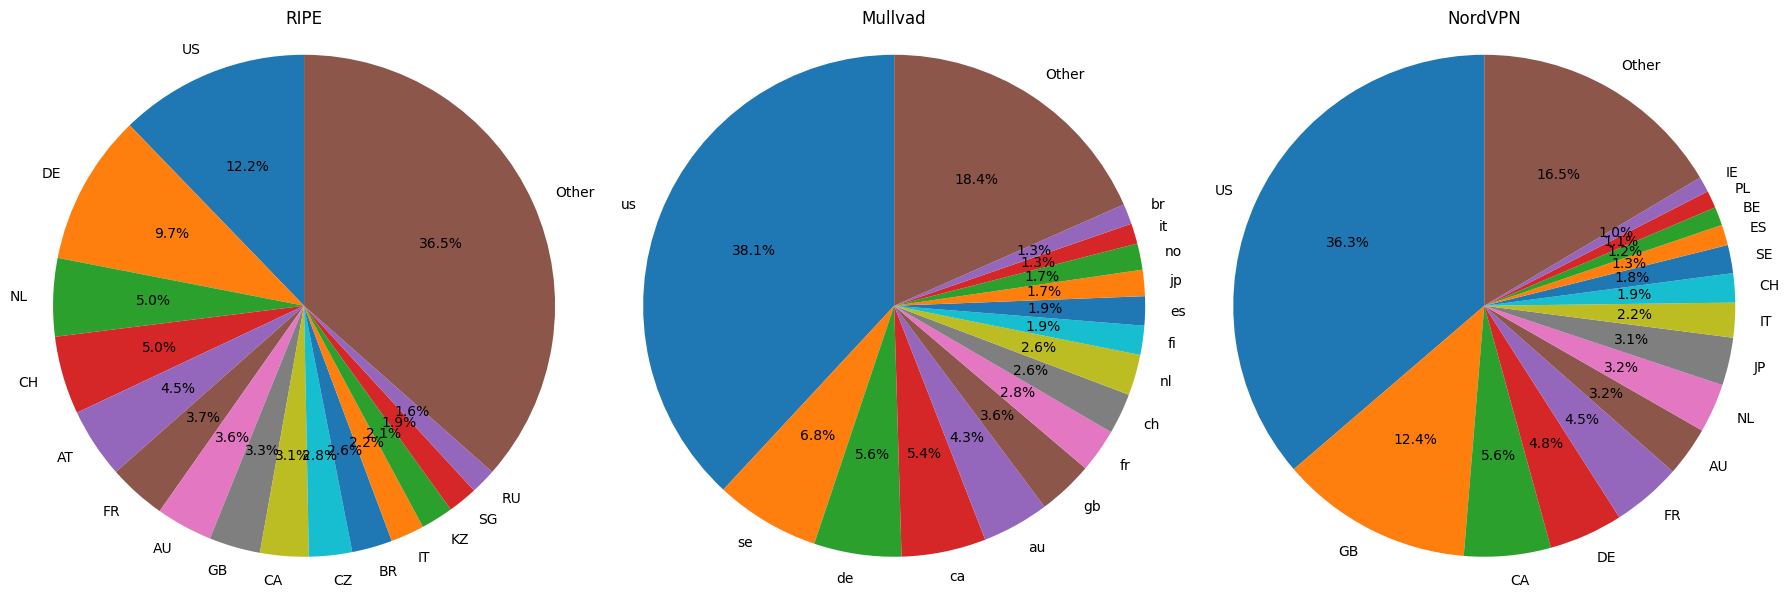

In [64]:
import matplotlib.pyplot as plt

counts = measurements.groupby(['origin', 'ground_truth']).size().reset_index(name='count')

# Separate each origins 
origins = measurements['origin'].unique()
fig, axes = plt.subplots(1, 3, figsize=(18,6))

for ax, origin in zip(axes, origins):
    origin_counts = counts[counts['origin'] == origin].copy()
    origin_counts.sort_values('count', ascending=False, inplace=True)
    # Group small slices (optional)
    if len(origin_counts) > 5:
        top = origin_counts.iloc[:15]
        other_sum = origin_counts.iloc[15:]['count'].sum()
        top = pd.concat([top, pd.DataFrame({'origin': [origin], 'ground_truth': ['Other'], 'count': [other_sum]})])
    else:
        top = origin_counts
    ax.pie(top['count'], labels=top['ground_truth'], autopct='%1.1f%%', startangle=90)
    ax.set_title(f'{origin}')
    ax.axis('equal')

plt.tight_layout()
plt.show()

The dataset will be split into a training set, a dev set, and a test set, per Geron's own recommendations; thus holdout validation is our chosen validation technique, for now. The training set and dev set will come from our RIPE anchors. The final test set will come from our VPNs. We will go for stratified sampling on as to make sure both splits are representative of our whole dataset. 


In [ ]:
from sklearn.model_selection import train_test_split

min_samples = 2

# Keep only classes with at least min_samples
grouped = measurements.groupby(measurements.origin)
traindev_set = grouped.get_group("RIPE")
# otherwise won't be able to stratify 
# see: https://github.com/davidsbatista/text-classification/issues/1
traindev_set = traindev_set[traindev_set.groupby("ground_truth")["ground_truth"].transform("size") >= min_samples]

# test size -> 0.2 means 20% 
# the stratification is essential as it means the distribution of classes is identical
train_set, dev_set = train_test_split(traindev_set, test_size=0.2, stratify=traindev_set["ground_truth"], random_state=1312)
train_set.describe()

,latency,hops,count
count,900.000000,900.000000,900.0
mean,149.730378,14.706944,4.0
std,129.228281,3.944592,0.0
min,12.704750,1.000000,4.0
25%,45.616062,12.250000,4.0
50%,109.423250,15.000000,4.0
75%,214.364500,17.750000,4.0
max,717.971250,23.250000,4.0


Let's now take a look at the distribution of servers by country, and by origin. 

In [62]:
# If you want to count number of servers per country per origin
grouped: DataFrame = train_set.groupby(['ground_truth', 'origin']).size().reset_index(name='count')
grouped.sort_values(by="count", ascending=False).head(10)

,ground_truth,origin,count
74,US,RIPE,113
23,DE,RIPE,89
52,NL,RIPE,46
16,CH,RIPE,46
6,AT,RIPE,41
31,FR,RIPE,34
7,AU,RIPE,33
32,GB,RIPE,30
15,CA,RIPE,29
22,CZ,RIPE,25


In [63]:
import matplotlib.pyplot as plt

hist = grouped.plot(by="origin", column="ground_truth")

TypeError: no numeric data to plot